# 02 — Churn Model
### Telecom Income & Churn Modeling

**Goal:** predict which customers are likely to churn, so retention offers can be targeted proactively.

From notebook 01, we know two things that shape everything below:
- Churn is **imbalanced** (~27% churn rate) — so accuracy alone can be misleading.
- `lninc` and `zlnlong` are pre-computed transforms of other variables in the dataset — worth keeping an eye on, but not target leakage for *this* model since `churn` isn't derived from them.

We'll build two models — logistic regression and random forest — and compare them using metrics that actually matter for a retention use case.

## 1. Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_excel('../data/raw/TelcoExtraCSU-Global.xlsx', sheet_name='IMPORT')
df.shape

(1000, 34)

## 2. Why accuracy alone would fool us here

If we built a model that always predicted "no churn," how often would it be right? That's our **baseline** — any real model needs to beat this by more than accuracy alone suggests, because a model can match this baseline while being completely useless for actually catching churners.

In [3]:
baseline_accuracy = 1 - df['churn'].mean()
print(f"'Always predict no churn' baseline accuracy: {baseline_accuracy:.1%}")
print(f"Actual churn rate: {df['churn'].mean():.1%}")

'Always predict no churn' baseline accuracy: 72.6%
Actual churn rate: 27.4%


A model that hits 75% accuracy sounds good — until you realize doing *nothing* gets you 72.6%. This is why we'll lean on **precision**, **recall**, and **ROC-AUC** below, not just accuracy.

Quick definitions, since it's been a while:
- **Precision** — of the customers we *predicted* would churn, what fraction actually did? (Low precision = wasting retention offers on people who weren't leaving anyway.)
- **Recall** — of the customers who *actually* churned, what fraction did we catch? (Low recall = missing people we should have targeted.)
- **ROC-AUC** — how well the model ranks customers by churn risk overall, independent of where you set the decision threshold. 0.5 = random guessing, 1.0 = perfect.

## 3. Train/test split

We hold out 25% of the data as a test set the model never sees during training — this is how we get an honest read on performance, rather than grading the model on questions it already saw the answers to.

`stratify=y` keeps the same ~27% churn ratio in both the train and test sets, so the split doesn't accidentally skew the evaluation.

In [5]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, churn rate {y_train.mean():.1%}")
print(f"Test:  {X_test.shape[0]} rows, churn rate {y_test.mean():.1%}")

Train: 750 rows, churn rate 27.5%
Test:  250 rows, churn rate 27.2%


## 4. Model 1 — Logistic regression

Logistic regression is a natural starting point for binary classification because it is comparatively interpretable and produces probability estimates. It is sensitive to feature scale, so predictors are standardized using parameters learned from the training set only.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of churn

Notice: we fit the scaler on training data only (`fit_transform`), then just `transform` the test data with those same parameters. Fitting the scaler on the full dataset would leak information about the test set's distribution into training — a subtler cousin of the leakage problem we flagged with `lninc` in notebook 01.

In [11]:
print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, log_pred):.3f}")
print(f"Precision: {precision_score(y_test, log_pred):.3f}")
print(f"Recall:    {recall_score(y_test, log_pred):.3f}")
print(f"F1:        {f1_score(y_test, log_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, log_proba):.3f}")

=== Logistic Regression ===
Accuracy:  0.732
Precision: 0.510
Recall:    0.382
F1:        0.437
ROC-AUC:   0.789


## 5. Model 2 — Random forest

Random forest builds many decision trees on random subsets of data and features, then averages their votes. Two practical advantages over logistic regression here: it captures non-linear relationships and feature interactions without us having to specify them, and it doesn't need feature scaling (trees split on raw thresholds, not distances).

In [13]:
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)  # note: raw X_train, no scaling needed

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.3f}")
print(f"Precision: {precision_score(y_test, rf_pred):.3f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.3f}")
print(f"F1:        {f1_score(y_test, rf_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.3f}")

=== Random Forest ===
Accuracy:  0.756
Precision: 0.585
Recall:    0.353
F1:        0.440
ROC-AUC:   0.776


`max_depth=6` caps how deep each tree can grow. Without a limit, random forests tend to overfit — memorizing quirks of the training data rather than learning generalizable patterns. Capping depth is one simple way to keep that in check; we could also tune `n_estimators`, `min_samples_leaf`, etc. later.

## 6. Side-by-side comparison

In [15]:
results = pd.DataFrame({
    'Logistic Regression': [
        accuracy_score(y_test, log_pred),
        precision_score(y_test, log_pred),
        recall_score(y_test, log_pred),
        f1_score(y_test, log_pred),
        roc_auc_score(y_test, log_proba),
    ],
    'Random Forest': [
        accuracy_score(y_test, rf_pred),
        precision_score(y_test, rf_pred),
        recall_score(y_test, rf_pred),
        f1_score(y_test, rf_pred),
        roc_auc_score(y_test, rf_proba),
    ],
}, index=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']).round(3)

results

,Logistic Regression,Random Forest
Accuracy,0.732,0.756
Precision,0.510,0.585
Recall,0.382,0.353
F1,0.437,0.440
ROC-AUC,0.789,0.776


**Reading this table:** random forest has higher accuracy and precision on this held-out test set, while logistic regression has higher recall and ROC-AUC. Logistic regression identifies 26 churners compared with 24 for random forest. For this case study, logistic regression is the preferred model when the decision objective emphasizes churn detection, discrimination, interpretability, and more stable generalization. This is an objective-specific model-selection decision; no retention-contact versus missed-churn cost assumption is imposed here.

## 7. ROC curve

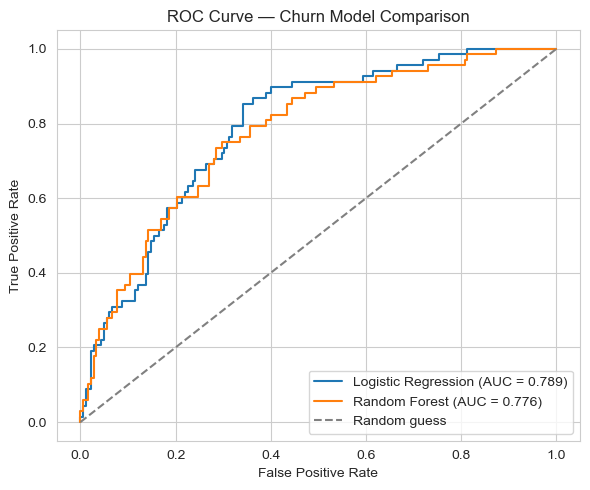

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))

for name, proba in [('Logistic Regression', log_proba), ('Random Forest', rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Churn Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Confusion matrix

The confusion matrix makes precision/recall concrete — it shows exactly which customers the model got wrong, and in which direction.

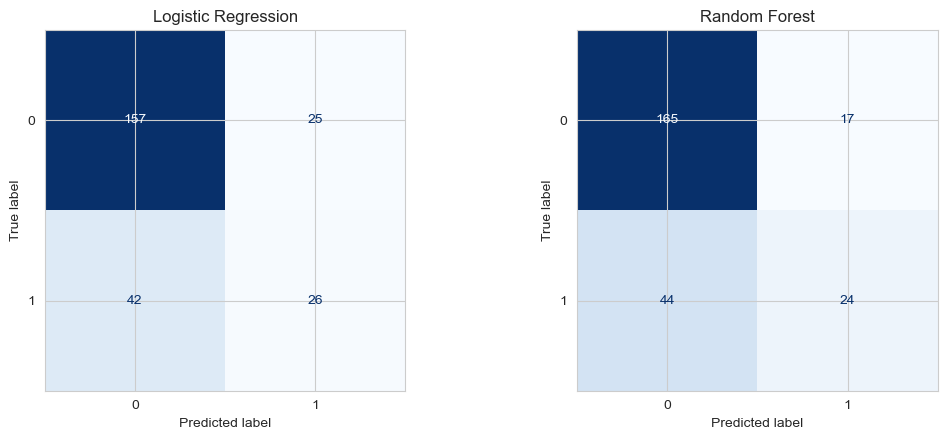

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, log_pred, ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

## 9. Which features contribute most to the random-forest predictions?

Random-forest feature importance ranks the variables the fitted trees relied on most for prediction. These values describe predictive contribution within this model; they do not establish causal churn drivers.

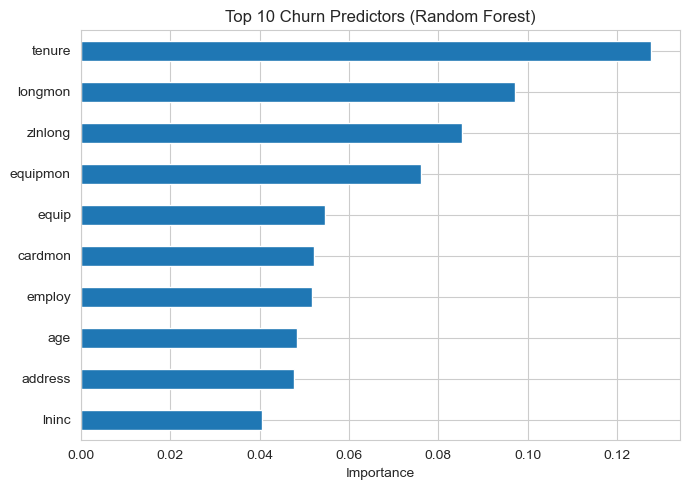

tenure      0.127679
longmon     0.097256
zlnlong     0.085201
equipmon    0.076081
equip       0.054554
cardmon     0.052186
employ      0.051789
age         0.048353
address     0.047756
lninc       0.040544
dtype: float64

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top 10 Churn Predictors (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

importances

**Reading this:** `tenure` has the highest random-forest feature importance, followed by long-distance and equipment-related measures among the leading signals. These patterns identify predictive associations in this dataset. They should not be interpreted as evidence that changing any one of these variables would cause churn to increase or decrease.

## Summary

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Majority-class baseline | 72.6% | — | 0.0% | — | 0.500 |
| Logistic Regression | 73.2% | 51.0% | **38.2%** | 43.7% | **0.790** |
| Random Forest | **75.6%** | **58.5%** | 35.3% | **44.0%** | 0.776 |

**Model-selection decision:** logistic regression is preferred for this case study when the objective emphasizes recall, ROC-AUC, interpretability, and more stable generalization. Random forest achieves higher accuracy and precision, but separate validation identified a material train/test overfitting concern.

**Limitations:** churn prevalence is 27.4%; recall remains modest; results use a single 75/25 holdout split; and class weighting, resampling, SMOTE, threshold optimization, and repeated cross-validation were not part of the validated implementation.

**Future development:** class weighting or other imbalance treatments, threshold optimization, repeated cross-validation, and alternative boosting models can be evaluated in later work.

Next: `03_income_model.ipynb`